In [4]:
import numpy as np

import sys
sys.path.append(r"C:\nirfasterFF")  # Path to your package
import nirfasterff



data = np.load("C:/nirfasterFF/Works/sensitivity/abs_us_z_scan/Saved data/save 1/numpy_data.npz",allow_pickle=True)
mesh = data["mesh"].item()
meshT = data["meshT"].item()
banana_ac = data["banana_ac"]
banana1 = data["banana1"]
J_md = data["J_md"]
J0 = data["J0"]
J_ac = data["J_ac"]
xgrid = data["xgrid"]
ygrid = data["ygrid"]
zgrid = data["zgrid"]
selection = data["selection"]
print(banana_ac.shape)


(120, 120, 120)


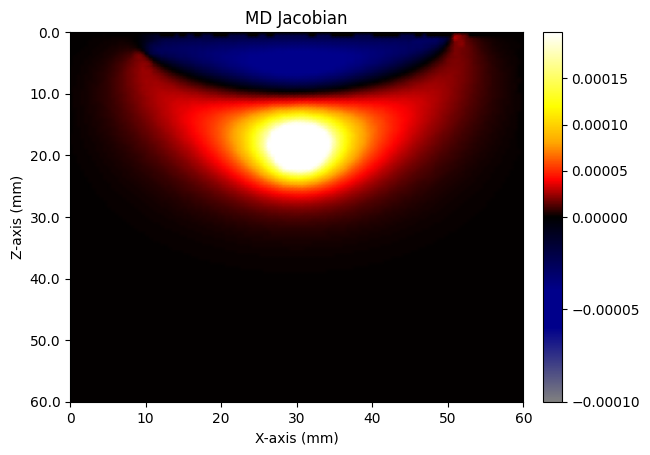

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Reshape J_md to match the grid size
banana_md = J_md.reshape((xgrid.size, ygrid.size, zgrid.size), order='f')


norm = mcolors.TwoSlopeNorm(vmin=-0.1e-3, vcenter=0, vmax=0.2e-3)

# Create a custom colormap
cmap_colors = [
    (0, "grey"),  
    (0.2, "darkblue"),
    (0.3, "darkblue"),
    (0.5, "black"),     
    (0.6, "red"),    
    (0.7, "orange"),      
    (0.8, "yellow"),
    (1.0, "white")     
]
custom_cmap = mcolors.LinearSegmentedColormap.from_list("custom_hot_blue", cmap_colors, N=500)


# Plot using imshow
#h = plt.imshow(-banana_md[30, :, :].T, origin='lower', cmap=custom_cmap, norm=norm,extent = [0, 60, 0, 60])


# Plot using `pcolormesh` for smooth shading
X, Z = np.meshgrid(np.linspace(0, 60, banana1.shape[1]),  
                   np.linspace(0, 60, banana1.shape[2]))
h = plt.pcolormesh(X, Z, -banana_md[60, :, :].T, cmap=custom_cmap, norm=norm, shading='gouraud')

# Add colorbar
plt.colorbar(h, fraction=0.046, pad=0.04)


#Invert z axis
yticks = plt.gca().get_yticks()  # Get the original tick positions
plt.gca().set_yticks(yticks)  # Set them back
plt.gca().set_yticklabels(yticks[::-1])



# Show plot
plt.xlabel("X-axis (mm)")
plt.ylabel("Z-axis (mm)")
plt.title("MD Jacobian")
plt.show()


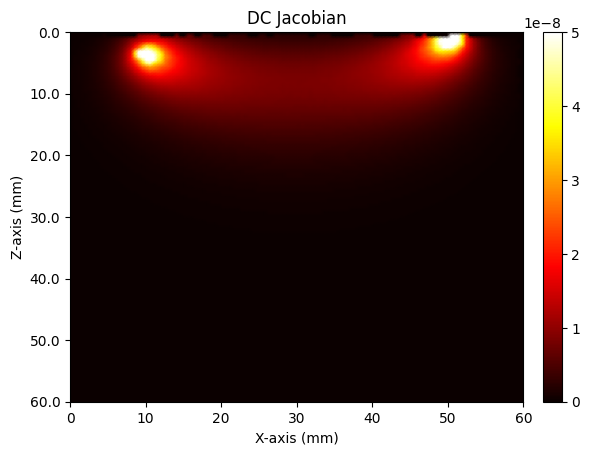

In [8]:
# plot the DC banana
banana1 = J0.reshape((xgrid.size, ygrid.size, zgrid.size), order='f') 



#plot with imshow
# plt.set_cmap('hot')
# h = plt.imshow(-banana1[60,:,:].T, origin='lower',vmin=0,vmax=1e-7,extent = [0, 60, 0, 60])




#Plot using `pcolormesh` for smooth shading
X, Z = np.meshgrid(np.linspace(0, 60, banana1.shape[1]),  
                   np.linspace(0, 60, banana1.shape[2]))

cmap = plt.get_cmap('hot')  
norm = mcolors.Normalize(vmin=0, vmax=0.5e-7)  
h = plt.pcolormesh(X, Z, -banana1[60, :, :].T, cmap=cmap, norm=norm, shading='gouraud')

plt.colorbar(h, fraction=0.046, pad=0.04)


yticks = plt.gca().get_yticks()  # Get the original tick positions
plt.gca().set_yticks(yticks)  # Set them back
plt.gca().set_yticklabels(yticks[::-1])


plt.xlabel("X-axis (mm)")
plt.ylabel("Z-axis (mm)")
plt.title("DC Jacobian")
plt.show()